# Estimación de peso de pollos

## Colegio de Posgraduados

### COA661 Inteligencia Artificial

Profesor: Dr. Juan Manuel González Camacho

Entrega: José Alfredo Martínez

En este notebook se realiza el análisis de datos previo al entrenamiento de modelos

In [1]:
# Librerias
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import joblib
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.pyplot as plt

## Código

In [2]:
# Cargar datos
datos = pd.read_excel('datosPesoPollo.xlsx')
fil, col = datos.shape

## Matriz de correlación entre $X$ y $Y$

<Axes: >

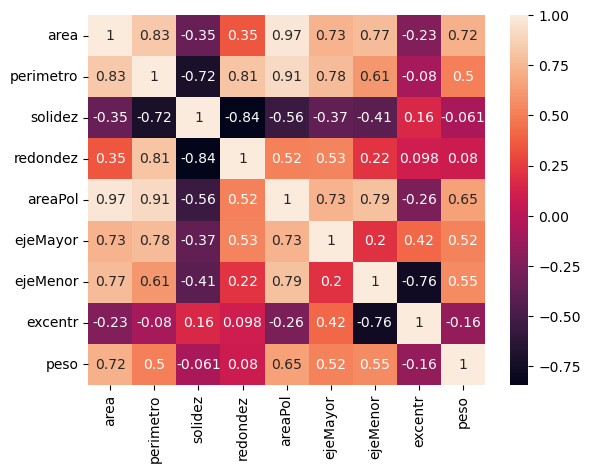

In [3]:
# Matriz de correlación
m = datos.iloc[:, 1 : col].corr()
sns.heatmap(m, annot = True)

In [4]:
# Datos
X = datos.iloc[:, 1 : col - 1].to_numpy()
Y = datos.iloc[:, col - 1].to_numpy()

In [5]:
# Datos de entrenamiento y test, aplicar proporción 80 : 20
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

print('Datos de entrenamiento: ', X_train.shape[0])
print('Datos de test: ', X_test.shape[0])

Datos de entrenamiento:  2439
Datos de test:  610


## Elegir 5 características que más aportan al peso

In [6]:
# Extraer 5 características que más aportan al peso
# area, perimetro, areaPol, ejeMayor, ejeMenor
X_train5 = X_train[:, [0, 1, 4, 5, 6]]
X_test5 = X_test[:, [0, 1, 4, 5, 6]]

Se eligen area, perimetro, areaPol, ejeMayor y ejeMenor

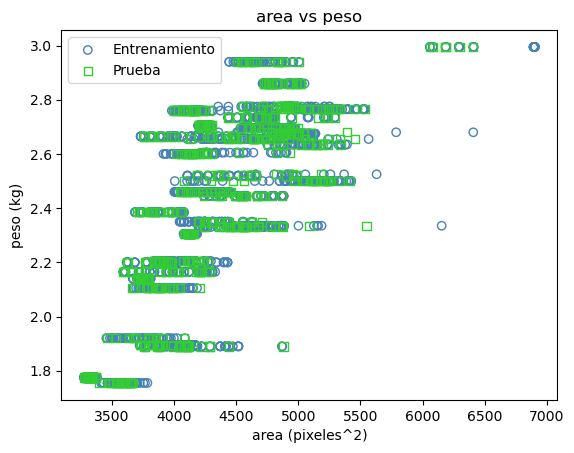

In [7]:
# Graficar área y peso
plt.scatter(X_train5[:, 0], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test5[:, 0], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Prueba')

plt.xlabel('area (pixeles^2)')
plt.ylabel('peso (kg)')

plt.title('area vs peso')
plt.legend(loc = 'upper left')

plt.show()

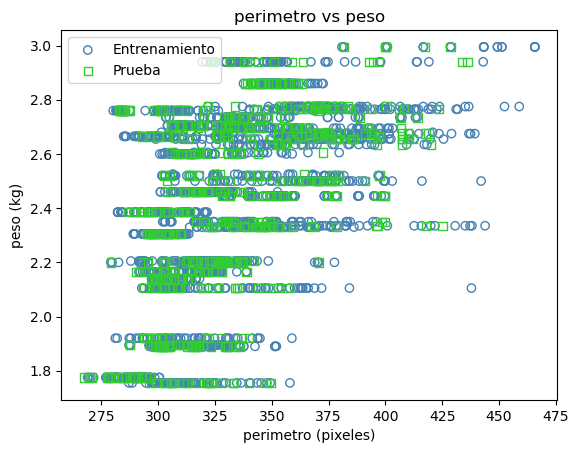

In [8]:
# Graficar área y peso
plt.scatter(X_train5[:, 1], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test5[:, 1], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Prueba')

plt.xlabel('perimetro (pixeles)')
plt.ylabel('peso (kg)')

plt.title('perimetro vs peso')
plt.legend(loc = 'upper left')

plt.show()

## Importancia de características usando Random Forest

In [9]:
etiquetas = datos.columns[1 : col]

forest = RandomForestRegressor(n_estimators = 500, random_state = 42)
forest.fit(X_train, Y_train)

importancias = forest.feature_importances_

caracteristicas = pd.Series(importancias, index = datos.iloc[:, 1 : col - 1].columns)
caracteristicas = caracteristicas.sort_values(ascending = False)
acumulado = np.cumsum(caracteristicas.values)

print(caracteristicas)

area         0.642256
solidez      0.079118
ejeMayor     0.063649
ejeMenor     0.061147
excentr      0.054840
redondez     0.041367
perimetro    0.030512
areaPol      0.027110
dtype: float64


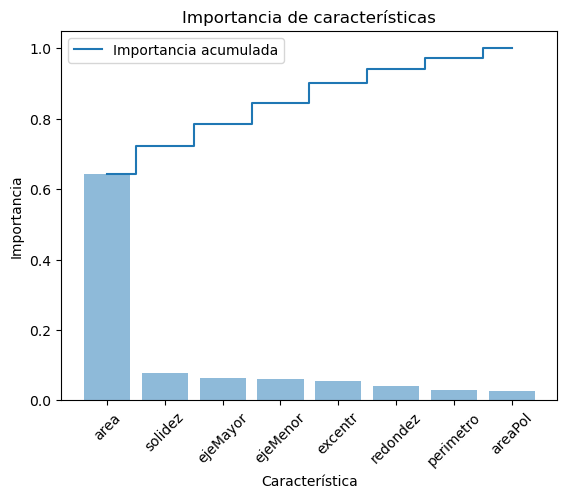

Acumulado: [0.64225608 0.72137394 0.78502323 0.84617055 0.90101089 0.94237827
 0.97289036 1.        ]


In [10]:
plt.bar(caracteristicas.index, caracteristicas.values, alpha = 0.5)
plt.step(range(0, caracteristicas.shape[0]), acumulado, where = 'mid', label = 'Importancia acumulada')

plt.ylabel('Importancia')
plt.xlabel('Característica')
plt.xticks(rotation = 45)

plt.title('Importancia de características')
plt.legend(loc = 'upper left')

plt.show()

print('Acumulado:', acumulado)

Mediante este método se eligen las primeras 4 características acumulando el 84.610% de la importancia

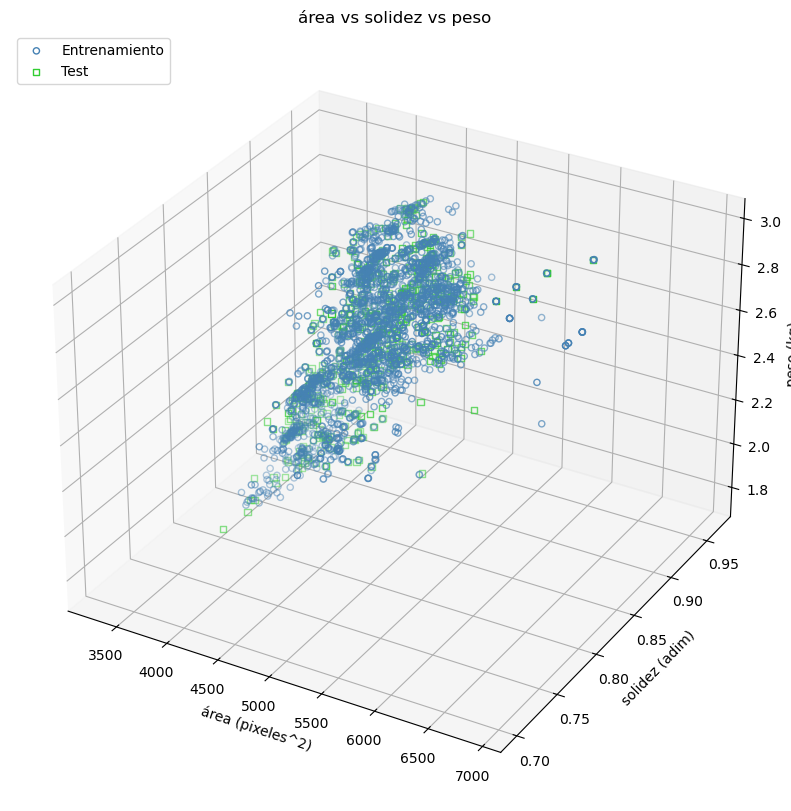

In [11]:
# Graficar datos
fig = plt.figure(figsize = [10, 10])
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(X_train[:, 0], X_train[:, 2], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', label = 'Entrenamiento')
ax.scatter(X_test[:, 0], X_test[:, 2], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', label = 'Test')

ax.set_xlabel('área (pixeles^2)')
ax.set_ylabel('solidez (adim)')
ax.set_zlabel('peso (kg)')

ax.set_title('área vs solidez vs peso')
ax.legend(loc = 'upper left')
plt.show()

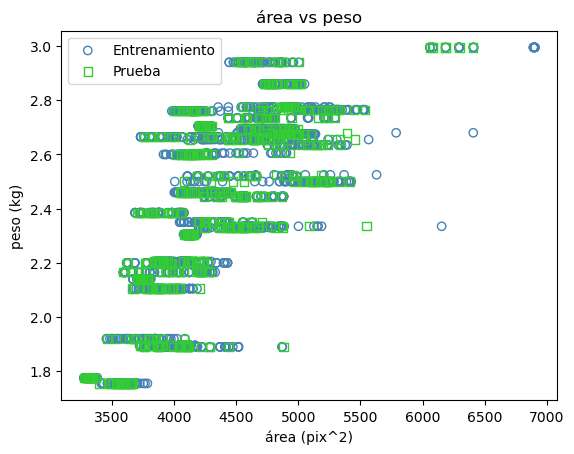

In [12]:
plt.scatter(X_train[:, 0], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test[:, 0], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Prueba')

plt.xlabel('área (pix^2)')
plt.ylabel('peso (kg)')

plt.title('área vs peso')
plt.legend(loc = 'upper left')

plt.show()

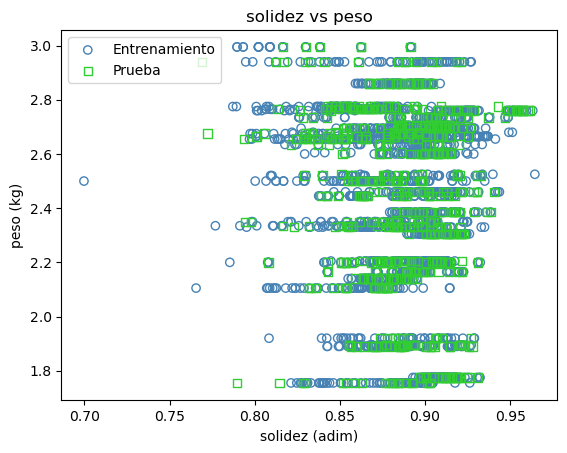

In [13]:
plt.scatter(X_train[:, 2], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test[:, 2], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Prueba')

plt.xlabel('solidez (adim)')
plt.ylabel('peso (kg)')

plt.title('solidez vs peso')
plt.legend(loc = 'upper left')

plt.show()

## Principal Component Analisis PCA

In [14]:
# Estandarizar los datos de entrada
scx = StandardScaler()

X_train_std = scx.fit_transform(X_train)
X_test_std = scx.transform(X_test)

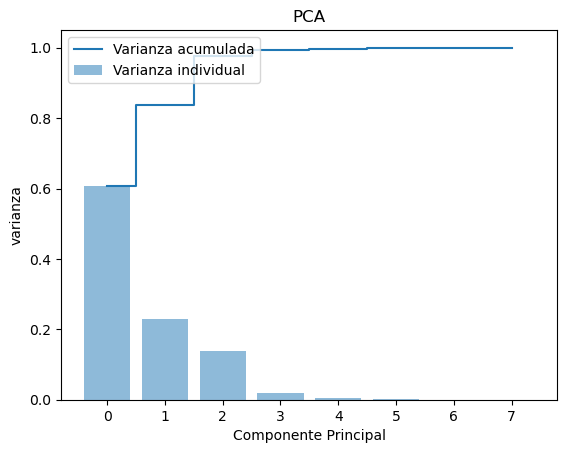

[0.60608245 0.83629209 0.97521536 0.99292716 0.99773186 0.9997677
 0.99991801 1.        ]


In [15]:
matriz_cov = np.cov(np.transpose(X_train_std))

eigen_vals, eigen_vecs = np.linalg.eig(matriz_cov)

total = sum(eigen_vals)
valores = [(i / total) for i in sorted(eigen_vals, reverse = True)]
acumulado = np.cumsum(valores)

plt.bar(range(0, len(valores)), valores, alpha = 0.5, align = 'center', label = 'Varianza individual')
plt.step(range(0, len(acumulado)), acumulado, where = 'mid', label = 'Varianza acumulada')

plt.ylabel('varianza')
plt.xlabel('Componente Principal')

plt.title('PCA')
plt.legend(loc = 'upper left')

plt.show()

print(acumulado)

Se toman 4 componentes principales que acumulan el 99.29% de la varianza

In [16]:
# Calcular matriz de 4 componentes
pca3 = PCA(n_components = 4)
X_train_pca3 = pca3.fit_transform(X_train_std)
X_test_pca3 = pca3.transform(X_test_std)

print(X_train_pca3.shape)

(2439, 4)


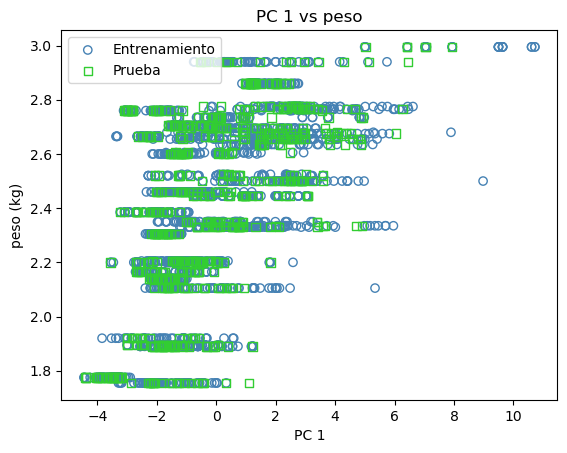

In [17]:
plt.scatter(X_train_pca3[:, 0], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test_pca3[:, 0], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Prueba')

plt.xlabel('PC 1')
plt.ylabel('peso (kg)')

plt.title('PC 1 vs peso')
plt.legend(loc = 'upper left')

plt.show()

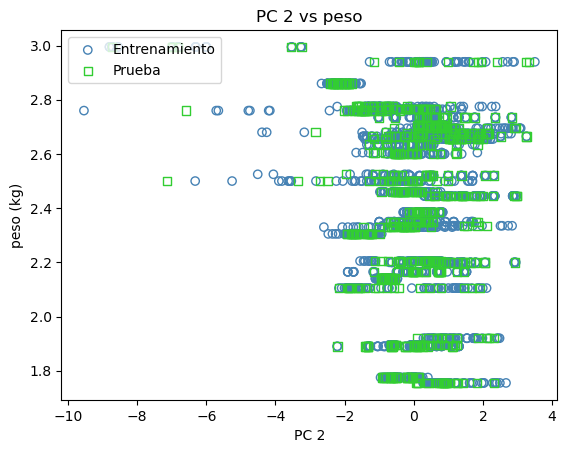

In [18]:
plt.scatter(X_train_pca3[:, 1], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test_pca3[:, 1], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Prueba')

plt.xlabel('PC 2')
plt.ylabel('peso (kg)')

plt.title('PC 2 vs peso')
plt.legend(loc = 'upper left')

plt.show()

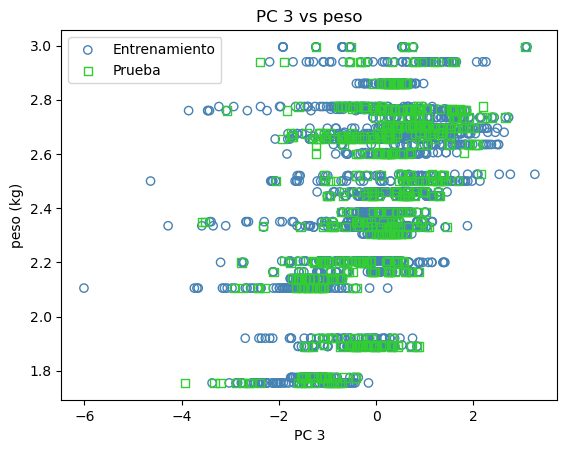

In [19]:
plt.scatter(X_train_pca3[:, 2], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test_pca3[:, 2], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Prueba')

plt.xlabel('PC 3')
plt.ylabel('peso (kg)')

plt.title('PC 3 vs peso')
plt.legend(loc = 'upper left')

plt.show()

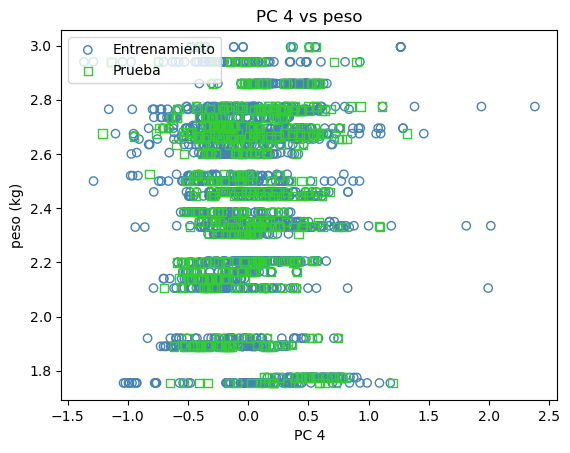

In [20]:
plt.scatter(X_train_pca3[:, 3], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test_pca3[:, 3], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Prueba')

plt.xlabel('PC 4')
plt.ylabel('peso (kg)')

plt.title('PC 4 vs peso')
plt.legend(loc = 'upper left')

plt.show()